In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import os

print(os.listdir('/content/drive/MyDrive'))

['Screenshot_2025-04-03-22-29-20-67_4336b74596784d9a2aa81f87c2016f50.jpg', 'IMG_20240728_030723_177.jpg', 'Classroom', 'IMG20240816005029.jpg', 'Lecture 01.gdoc', 'phy chem Vishal.pdf', 'IMG_20240911_230440 (1).jpg', 'IMG_20240911_230440.jpg', 'IMG_20240911_230450.jpg', 'vishal.pdf', 'Functions 2 (2).gdoc', 'Functions 2 (1).gdoc', 'Functions 2.gdoc', 'Screenshot_2024-09-16-13-02-34-04_99c04817c0de5652397fc8b56c3b3817.jpg', 'Module 1_Lecture#1 to Lecture#7.gdoc', '1. Intro to quantum mechanics cx85d.gdoc', 'IMG_20240922_224549.jpg', 'Screenshot_2024-10-04-17-24-11-94_99c04817c0de5652397fc8b56c3b3817.jpg', 'Aaditiya(B24MT1001_A6)Math Assignment 02.pdf', 'IMG20241013195010.jpg', 'Derivative-I 2.gdoc', 'Document from vishalvsc07 (3)', '_PHP1010-Physics_Laboratory_Manual-24August.docx (1).gdoc', 'Lecture-1 Electromagnetic wave Part-1.gdoc', 'Lecture-2 Electromagnetic wave in conductor (1).gdoc', 'Lecture-2 Electromagnetic wave in conductor.gdoc', 'B24BB1043_QR.png', 'Timetable Sem ||.jpg', 

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
import zipfile

zip_path = "/content/drive/MyDrive/Pediatric Chest X-ray Pneumonia.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content/dataset')

print("Dataset Extracted Successfully")

Dataset Extracted Successfully


In [7]:
import os

print(os.listdir('/content/dataset'))


['Pediatric Chest X-ray Pneumonia']


In [8]:
import os

for root, dirs, files in os.walk('/content/dataset'):
    print(root)

/content/dataset
/content/dataset/Pediatric Chest X-ray Pneumonia
/content/dataset/Pediatric Chest X-ray Pneumonia/train
/content/dataset/Pediatric Chest X-ray Pneumonia/train/PNEUMONIA
/content/dataset/Pediatric Chest X-ray Pneumonia/train/NORMAL
/content/dataset/Pediatric Chest X-ray Pneumonia/test
/content/dataset/Pediatric Chest X-ray Pneumonia/test/PNEUMONIA
/content/dataset/Pediatric Chest X-ray Pneumonia/test/NORMAL


In [9]:
train_path = "/content/dataset/Pediatric Chest X-ray Pneumonia/train"
test_path = "/content/dataset/Pediatric Chest X-ray Pneumonia/test"

In [10]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    train_path,
    target_size=(150,150),
    batch_size=32,
    class_mode='binary'
)

test_data = test_datagen.flow_from_directory(
    test_path,
    target_size=(150,150),
    batch_size=32,
    class_mode='binary'
)

Found 5232 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


In [11]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu', input_shape=(150,150,3)))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [13]:
history = model.fit(
    train_data,
    validation_data=test_data,
    epochs=5
)

Epoch 1/5
164/164 ━━━━━━━━━━━━━━━━━━━━ 144s 869ms/step - accuracy: 0.9169 - loss: 0.2318 - val_accuracy: 0.7276 - val_loss: 1.0664
Epoch 2/5
164/164 ━━━━━━━━━━━━━━━━━━━━ 200s 859ms/step - accuracy: 0.9700 - loss: 0.0864 - val_accuracy: 0.7853 - val_loss: 0.6862
Epoch 3/5
164/164 ━━━━━━━━━━━━━━━━━━━━ 140s 854ms/step - accuracy: 0.9776 - loss: 0.0597 - val_accuracy: 0.7580 - val_loss: 1.1113
Epoch 4/5
164/164 ━━━━━━━━━━━━━━━━━━━━ 146s 891ms/step - accuracy: 0.9822 - loss: 0.0474 - val_accuracy: 0.7324 - val_loss: 1.6374
Epoch 5/5
164/164 ━━━━━━━━━━━━━━━━━━━━ 198s 861ms/step - accuracy: 0.9776 - loss: 0.0602 - val_accuracy: 0.7356 - val_loss: 1.4989


In [14]:
loss, accuracy = model.evaluate(test_data)

print("Test Accuracy:", accuracy)
print("Test Loss:", loss)

20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 279ms/step - accuracy: 0.7356 - loss: 1.4989
Test Accuracy: 0.7355769276618958
Test Loss: 1.4989272356033325


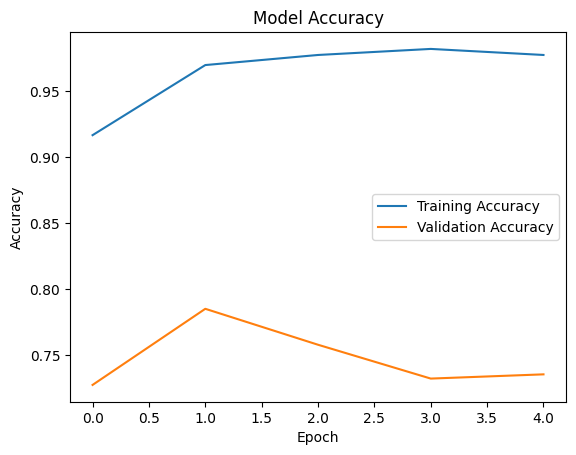

In [15]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Training Accuracy', 'Validation Accuracy'])

plt.show()

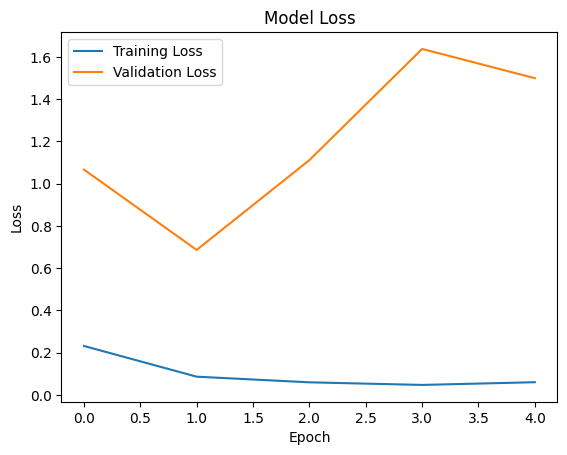

In [16]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Training Loss', 'Validation Loss'])

plt.show()

In [17]:
model.save("pneumonia_model.h5")

print("Model Saved Successfully")

Model Saved Successfully


In [19]:
from google.colab import files

files.download("pneumonia_model.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [20]:
from sklearn.metrics import confusion_matrix
import numpy as np

predictions = model.predict(test_data)
y_pred = (predictions > 0.5).astype(int)

cm = confusion_matrix(test_data.classes, y_pred)

print(cm)

20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 378ms/step
[[ 23 211]
 [ 50 340]]


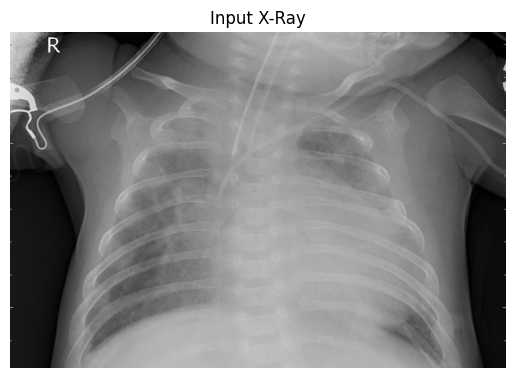

In [21]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

image_path = "/content/dataset/Pediatric Chest X-ray Pneumonia/test/PNEUMONIA/person1_virus_6.jpeg"

img = mpimg.imread(image_path)

plt.imshow(img, cmap='gray')
plt.title("Input X-Ray")
plt.axis("off")
plt.show()

In [22]:
from tensorflow.keras.preprocessing import image
import numpy as np

img = image.load_img(image_path, target_size=(150,150))

img_array = image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

print("Prediction Value:", prediction[0][0])

if prediction[0][0] > 0.5:
    print("Result: Pneumonia Detected")
else:
    print("Result: Normal Chest X-Ray")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step
Prediction Value: 0.99991393
Result: Pneumonia Detected


In [23]:
result = "Pneumonia Detected" if prediction[0][0] > 0.5 else "Normal Chest X-Ray"

print("================================")
print("CHEST X-RAY ANALYSIS RESULT")
print("================================")
print("Prediction:", result)
print("================================")

CHEST X-RAY ANALYSIS RESULT
Prediction: Pneumonia Detected


In [24]:
model.save("pneumonia_model.h5")

print("Model saved successfully!")

Model saved successfully!


In [25]:
from google.colab import files

files.download("pneumonia_model.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

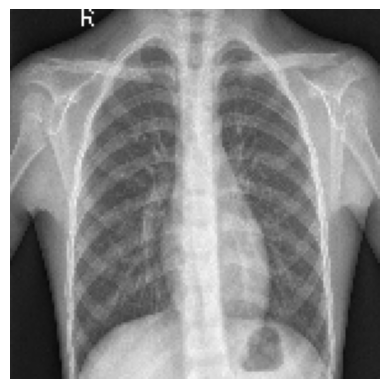

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
Prediction: Normal


In [26]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

image_path = "/content/dataset/Pediatric Chest X-ray Pneumonia/test/NORMAL/IM-0001-0001.jpeg"

img = image.load_img(image_path, target_size=(150,150))

plt.imshow(img)
plt.axis('off')
plt.show()

img_array = image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

if prediction[0][0] > 0.5:
    print("Prediction: Pneumonia")
else:
    print("Prediction: Normal")

In [27]:
model.save("pneumonia_model.h5")

print("Model Saved Successfully")

Model Saved Successfully
